In [5]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import json
import seaborn as sns
from PIL import Image

   filename  width  height  aspect_ratio format  mode
0     1.png   1106     832      1.329327    PNG  RGBA
1    10.png    538     687      0.783115    PNG   RGB
2    11.jpg   1000     658      1.519757   JPEG   RGB
3    12.png    979     638      1.534483    PNG  RGBA
4    13.png    977     692      1.411850    PNG  RGBA
5    14.png   1500     956      1.569038    PNG  RGBA
6    15.jpg    640     495      1.292929   JPEG   RGB
7    16.png    949     656      1.446646    PNG  RGBA
8    17.png    771     725      1.063448    PNG  RGBA
9    18.png    984     710      1.385915    PNG  RGBA
10   19.jpg   1200     867      1.384083   JPEG   RGB
11    2.png   1213     682      1.778592    PNG  RGBA
12   20.jpg    792     792      1.000000   JPEG   RGB
13   21.jpg    950     950      1.000000   JPEG   RGB
14   22.jpg     70      70      1.000000   JPEG   RGB
15   23.jpg   1200     867      1.384083   JPEG   RGB
16   24.jpg    950     950      1.000000   JPEG   RGB
17   25.jpg    950     950  

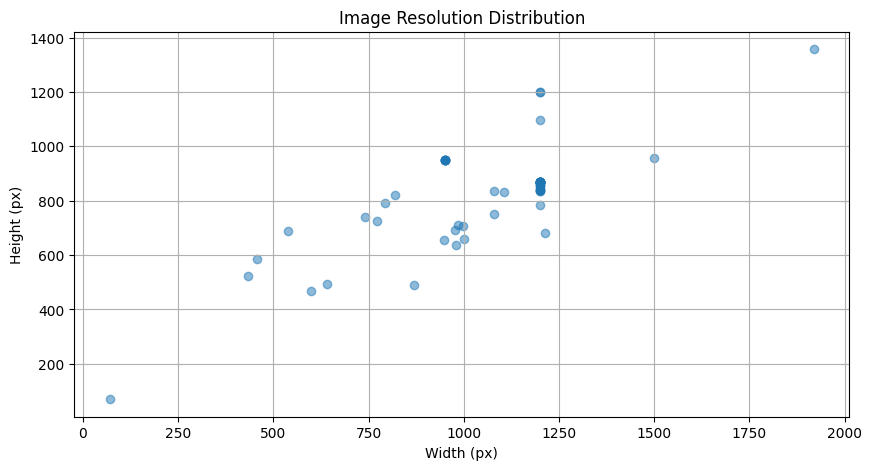

In [6]:
dataset_path = 'BOM-Dataset'
valid_formats = ('.jpg', '.jpeg', '.png', '.webp')

data = []
for filename in os.listdir(dataset_path):
    if filename.lower().endswith(valid_formats):
        img_path = os.path.join(dataset_path, filename)
        try:
            with Image.open(img_path) as img:
                width, height = img.size
                format = img.format
                mode = img.mode
                data.append({
                    'filename': filename,
                    'width': width,
                    'height': height,
                    'aspect_ratio': width / height,
                    'format': format,
                    'mode': mode
                })
        except Exception as e:
            print(f"Error loading {filename}: {e}")

df = pd.DataFrame(data)
print(df)

print(f"Total images found: {len(df)}")
print("\nFormat Distribution:\n", df['format'].value_counts())

plt.figure(figsize=(10, 5))
plt.scatter(df['width'], df['height'], alpha=0.5)
plt.title('Image Resolution Distribution')
plt.xlabel('Width (px)')
plt.ylabel('Height (px)')
plt.grid(True)
plt.show()

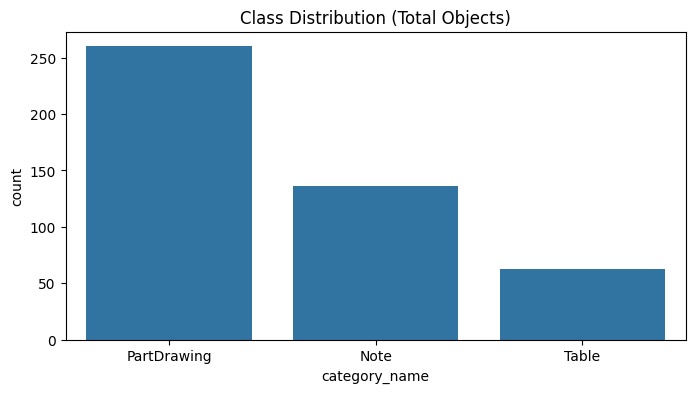

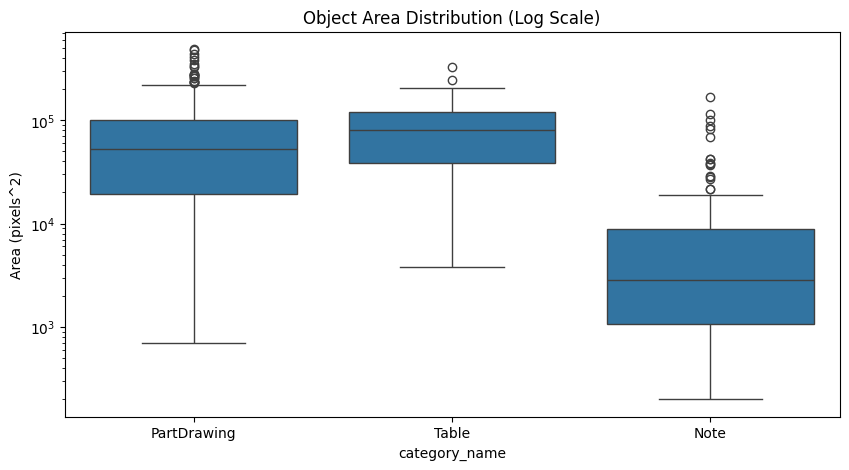

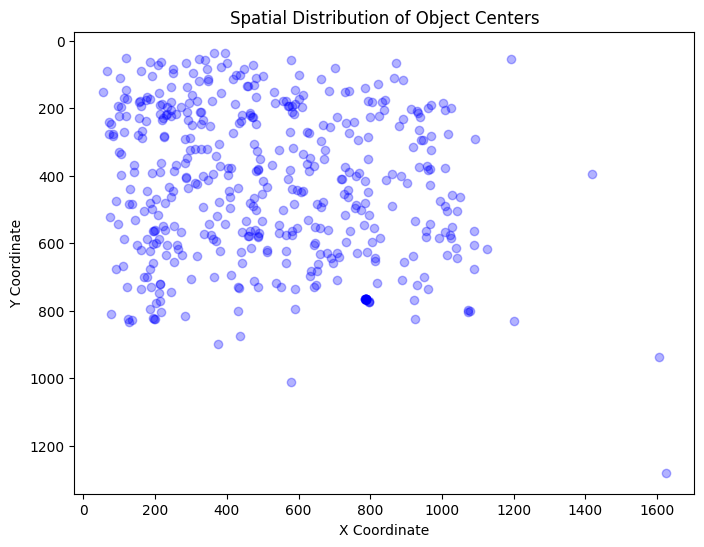

In [7]:
with open('instances_default.json', 'r') as f:
    coco_data = json.load(f)

images = pd.DataFrame(coco_data['images'])
annotations = pd.DataFrame(coco_data['annotations'])
categories = {cat['id']: cat['name'] for cat in coco_data['categories']}

annotations['category_name'] = annotations['category_id'].map(categories)

plt.figure(figsize=(8, 4))
sns.countplot(data=annotations, x='category_name', order=['PartDrawing', 'Note', 'Table'])
plt.title('Class Distribution (Total Objects)')
plt.show()

annotations['width'] = annotations['bbox'].apply(lambda x: x[2])
annotations['height'] = annotations['bbox'].apply(lambda x: x[3])
annotations['area'] = annotations['width'] * annotations['height']

plt.figure(figsize=(10, 5))
sns.boxplot(data=annotations, x='category_name', y='area')
plt.yscale('log')
plt.title('Object Area Distribution (Log Scale)')
plt.ylabel('Area (pixels^2)')
plt.show()

annotations['center_x'] = annotations['bbox'].apply(lambda x: x[0] + x[2]/2)
annotations['center_y'] = annotations['bbox'].apply(lambda x: x[1] + x[3]/2)

plt.figure(figsize=(8, 6))
plt.scatter(annotations['center_x'], annotations['center_y'], alpha=0.3, c='blue')
plt.gca().invert_yaxis()
plt.title('Spatial Distribution of Object Centers')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.show()